# Final Model Comparison and Test Evaluation

This notebook is the final evaluation for the retail demand forecasting project.

Model selection was completed using the 13 monthly validation windows. The test period is untouched until this notebook. Baseline models, selected Linear Regression, selected Prophet, and selected XGBoost candidates are evaluated once on the same 365-day test period.

The test results are reported as a final fixed comparison. They do not change the model setups selected during validation.

Main objectives:

1. Compare every model on the untouched test period.
2. Show the improvement from the Naive baseline to the more advanced models.
3. Compare validation and test performance for the validation-selected models.
4. Assess whether extra model complexity produced enough practical value.
5. Summarize the final findings, limitations, and next steps.


In [1]:
import pickle

import pandas as pd
import matplotlib.pyplot as plt

from prophet.serialize import model_from_json
from xgboost import XGBRegressor

import models
import models_metrics


In [2]:
train_data = pd.read_parquet(
    "data/processed/train_data.parquet"
)

validation_data = pd.read_parquet(
    "data/processed/validation_data.parquet"
)

test_data = pd.read_parquet(
    "data/processed/test_data.parquet"
)

pretest_data = pd.concat(
    [train_data, validation_data],
    ignore_index=True,
)

pretest_daily = (
    pretest_data
    .groupby(
        ["cat_id", "ds"],
        observed=True,
        as_index=False,
    )
    .agg(y=("y", "sum"))
    .sort_values(["cat_id", "ds"])
    .reset_index(drop=True)
)

test_daily = (
    test_data
    .groupby(
        ["cat_id", "ds"],
        observed=True,
        as_index=False,
    )
    .agg(y=("y", "sum"))
    .sort_values(["cat_id", "ds"])
    .reset_index(drop=True)
)


In [3]:
test_check = (
    test_daily
    .groupby("cat_id", observed=True)
    .agg(
        forecast_days=("ds", "size"),
        start=("ds", "min"),
        end=("ds", "max"),
    )
)

assert (test_check["forecast_days"] == 365).all()

test_check


,forecast_days,start,end
cat_id,,,
HOBBIES,365,2015-06-21,2016-06-19
HOUSEHOLD,365,2015-06-21,2016-06-19
FOODS,365,2015-06-21,2016-06-19


In [4]:
all_validation_summary = pd.read_parquet(
    "data/processed/all_model_validation_summary.parquet"
)

validation_winners = (
    all_validation_summary
    .sort_values(
        ["cat_id", "Mean_WAPE", "Std_WAPE"]
    )
    .groupby(
        "cat_id",
        observed=True,
    )
    .first()
    .reset_index()
)

validation_winners


,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,XGBoost Faster,1698.63,2323.12,6.99,1.91,4.16,10.33
1,HOBBIES,Linear Regression (Full),223.04,290.39,6.50,1.48,4.73,9.14
2,HOUSEHOLD,Prophet Flexible,581.16,765.08,6.88,1.99,3.31,10.72


## Test Forecasts

The baseline models are refitted on all pre-test history. The saved Linear Regression, Prophet, and XGBoost candidates are loaded without changing their validated setup.


In [5]:
def make_feature_row(history, forecast_date, columns):

    forecast_features = pd.DataFrame(
        {
            "lag_1": [history[-1]],
            "lag_7": [history[-7]],
            "lag_14": [history[-14]],
            "lag_28": [history[-28]],
            "rolling_mean_7": [sum(history[-7:]) / 7],
            "rolling_mean_28": [sum(history[-28:]) / 28],
            "time_index": [len(history)],
            "is_christmas": [
                int(
                    forecast_date.month == 12
                    and forecast_date.day == 25
                )
            ],
            "day_of_week": [forecast_date.dayofweek],
            "month": [forecast_date.month],
        }
    )

    forecast_features = pd.get_dummies(
        forecast_features,
        columns=["day_of_week", "month"],
        dtype=int,
    )

    return forecast_features.reindex(
        columns=columns,
        fill_value=0,
    )


In [6]:
test_forecast_records = []

for category in pretest_daily["cat_id"].unique():

    train = pretest_daily[
        pretest_daily["cat_id"] == category
    ].sort_values("ds")

    test = test_daily[
        test_daily["cat_id"] == category
    ].sort_values("ds")

    for model_name, forecast_function in (
        models.MODEL_FUNCTIONS.items()
    ):

        forecast = forecast_function(
            train=train["y"],
            horizon=len(test),
        )

        for date, actual, prediction in zip(
            test["ds"],
            test["y"],
            forecast,
        ):
            test_forecast_records.append(
                {
                    "cat_id": category,
                    "ds": date,
                    "Model": model_name,
                    "actual": actual,
                    "forecast": prediction,
                }
            )


/Users/joseclaudio/opt/anaconda3/envs/portfolio/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/joseclaudio/opt/anaconda3/envs/portfolio/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/joseclaudio/opt/anaconda3/envs/portfolio/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/joseclaudio/opt/anaconda3/envs/portfolio/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.p

/Users/joseclaudio/opt/anaconda3/envs/portfolio/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/joseclaudio/opt/anaconda3/envs/portfolio/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [7]:
with open(
    "data/models/linear_regression_models.pkl",
    "rb",
) as file:
    linear_models = pickle.load(file)

for category, saved_model in linear_models.items():

    train = pretest_daily[
        pretest_daily["cat_id"] == category
    ].sort_values("ds")

    test = test_daily[
        test_daily["cat_id"] == category
    ].sort_values("ds")

    history = train["y"].astype(float).tolist()
    forecasts = []

    for forecast_date in test["ds"]:

        feature_row = make_feature_row(
            history,
            forecast_date,
            saved_model["selected_features"],
        )

        prediction = saved_model["model"].predict(
            saved_model["scaler"].transform(feature_row)
        )[0]

        prediction = max(0, prediction)

        forecasts.append(prediction)
        history.append(prediction)

    for date, actual, prediction in zip(
        test["ds"],
        test["y"],
        forecasts,
    ):
        test_forecast_records.append(
            {
                "cat_id": category,
                "ds": date,
                "Model": saved_model["selected_version"],
                "actual": actual,
                "forecast": prediction,
            }
        )


In [8]:
prophet_parameters = pd.read_parquet(
    "data/processed/prophet_best_parameters.parquet"
)

for category in pretest_daily["cat_id"].unique():

    test = test_daily[
        test_daily["cat_id"] == category
    ].sort_values("ds")

    model_name = prophet_parameters.loc[
        prophet_parameters["cat_id"] == category,
        "Model",
    ].iloc[0]

    with open(
        f"data/models/prophet_pretest_{category}.json",
        "r",
    ) as file:
        prophet_model = model_from_json(
            file.read()
        )

    forecast = prophet_model.predict(
        test[["ds"]]
    )["yhat"].clip(lower=0)

    for date, actual, prediction in zip(
        test["ds"],
        test["y"],
        forecast,
    ):
        test_forecast_records.append(
            {
                "cat_id": category,
                "ds": date,
                "Model": model_name,
                "actual": actual,
                "forecast": prediction,
            }
        )


In [9]:
xgboost_parameters = pd.read_parquet(
    "data/processed/xgboost_best_parameters.parquet"
)

for category in pretest_daily["cat_id"].unique():

    train = pretest_daily[
        pretest_daily["cat_id"] == category
    ].sort_values("ds")

    test = test_daily[
        test_daily["cat_id"] == category
    ].sort_values("ds")

    model_name = xgboost_parameters.loc[
        xgboost_parameters["cat_id"] == category,
        "Model",
    ].iloc[0]

    xgboost_model = XGBRegressor()

    xgboost_model.load_model(
        f"data/models/xgboost_pretest_{category}.json"
    )

    feature_columns = (
        xgboost_model
        .get_booster()
        .feature_names
    )

    history = train["y"].astype(float).tolist()
    forecasts = []

    for forecast_date in test["ds"]:

        feature_row = make_feature_row(
            history,
            forecast_date,
            feature_columns,
        )

        prediction = xgboost_model.predict(
            feature_row
        )[0]

        prediction = max(0, prediction)

        forecasts.append(prediction)
        history.append(prediction)

    for date, actual, prediction in zip(
        test["ds"],
        test["y"],
        forecasts,
    ):
        test_forecast_records.append(
            {
                "cat_id": category,
                "ds": date,
                "Model": model_name,
                "actual": actual,
                "forecast": prediction,
            }
        )


In [10]:
test_forecasts = pd.DataFrame(
    test_forecast_records
)

test_metric_records = []

for (category, model_name), group in (
    test_forecasts
    .groupby(
        ["cat_id", "Model"],
        observed=True,
    )
):

    metrics = models_metrics.calculate_validation_metrics(
        actual=group["actual"],
        forecast=group["forecast"],
    )

    test_metric_records.append(
        {
            "cat_id": category,
            "Model": model_name,
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "WAPE (%)": metrics["WAPE (%)"],
        }
    )

test_metrics = pd.DataFrame(
    test_metric_records
).round(2)

test_metrics


,cat_id,Model,MAE,RMSE,WAPE (%)
0,FOODS,7-Day SMA,3775.99,4936.33,14.17
1,FOODS,ETS,2849.77,3761.40,10.69
2,FOODS,Linear Regression (Reduced),2947.40,3789.83,11.06
3,FOODS,Naive,4289.66,5157.02,16.10
4,FOODS,Prophet Additive,3508.32,4292.03,13.16
5,FOODS,Seasonal Naive,3892.77,5156.33,14.61
6,FOODS,XGBoost Faster,2722.43,3536.01,10.22
7,HOBBIES,7-Day SMA,457.14,610.59,11.60
8,HOBBIES,ETS,320.18,453.68,8.12
9,HOBBIES,Linear Regression (Full),346.31,443.15,8.78


In [11]:
model_effort = {
    "Naive": "Low",
    "Seasonal Naive": "Low",
    "7-Day SMA": "Low",
    "ETS": "Medium",
    "Linear Regression (Full)": "Medium",
    "Linear Regression (Reduced)": "Medium",
    "Prophet Additive": "Medium",
    "Prophet Flexible": "Medium",
    "XGBoost Faster": "High",
    "XGBoost Shallow": "High",
}

naive_wape = (
    test_metrics
    .query("Model == 'Naive'")
    .set_index("cat_id")["WAPE (%)"]
)

test_report = test_metrics.copy()

test_report["Effort"] = test_report["Model"].map(
    model_effort
)

test_report["Improvement vs Naive (WAPE points)"] = (
    test_report["cat_id"].map(naive_wape)
    - test_report["WAPE (%)"]
).round(2)

test_report = test_report.sort_values(
    ["cat_id", "WAPE (%)"]
).reset_index(drop=True)

test_report


,cat_id,Model,MAE,RMSE,WAPE (%),Effort,Improvement vs Naive (WAPE points)
0,FOODS,XGBoost Faster,2722.43,3536.01,10.22,High,5.88
1,FOODS,ETS,2849.77,3761.40,10.69,Medium,5.41
2,FOODS,Linear Regression (Reduced),2947.40,3789.83,11.06,Medium,5.04
3,FOODS,Prophet Additive,3508.32,4292.03,13.16,Medium,2.94
4,FOODS,7-Day SMA,3775.99,4936.33,14.17,Low,1.93
5,FOODS,Seasonal Naive,3892.77,5156.33,14.61,Low,1.49
6,FOODS,Naive,4289.66,5157.02,16.10,Low,0.00
7,HOBBIES,XGBoost Shallow,315.22,423.95,8.00,High,9.47
8,HOBBIES,Prophet Flexible,316.92,400.51,8.04,Medium,9.43
9,HOBBIES,ETS,320.18,453.68,8.12,Medium,9.35


In [12]:
selected_test_results = (
    validation_winners[
        ["cat_id", "Model", "Mean_WAPE"]
    ]
    .rename(
        columns={
            "Model": "Validation-selected model",
            "Mean_WAPE": "Validation WAPE (%)",
        }
    )
    .merge(
        test_report[
            ["cat_id", "Model", "WAPE (%)"]
        ],
        left_on=[
            "cat_id",
            "Validation-selected model",
        ],
        right_on=["cat_id", "Model"],
        how="left",
    )
    .drop(columns="Model")
    .rename(
        columns={
            "WAPE (%)": "Test WAPE (%)",
        }
    )
)

selected_test_results[
    "Test minus validation (WAPE points)"
] = (
    selected_test_results["Test WAPE (%)"]
    - selected_test_results["Validation WAPE (%)"]
).round(2)

selected_test_results


,cat_id,Validation-selected model,Validation WAPE (%),Test WAPE (%),Test minus validation (WAPE points)
0,FOODS,XGBoost Faster,6.99,10.22,3.23
1,HOBBIES,Linear Regression (Full),6.50,8.78,2.28
2,HOUSEHOLD,Prophet Flexible,6.88,8.31,1.43


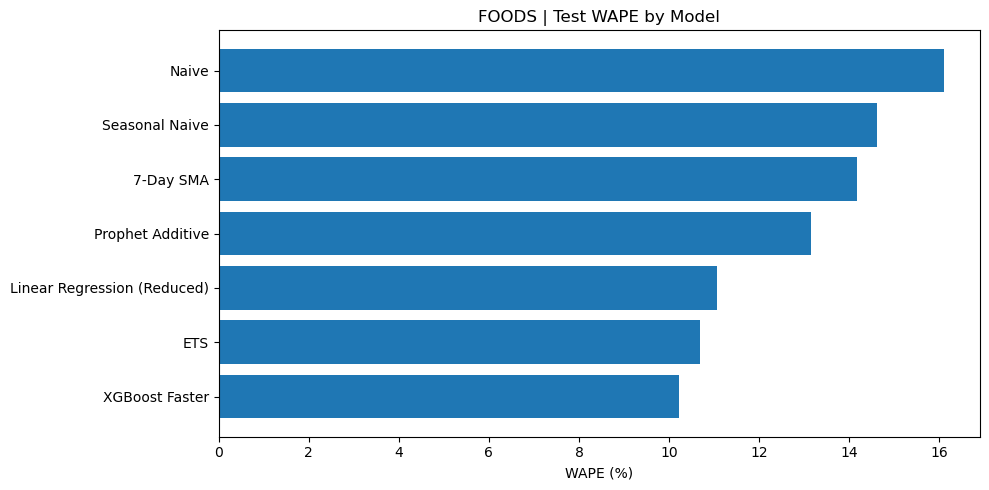

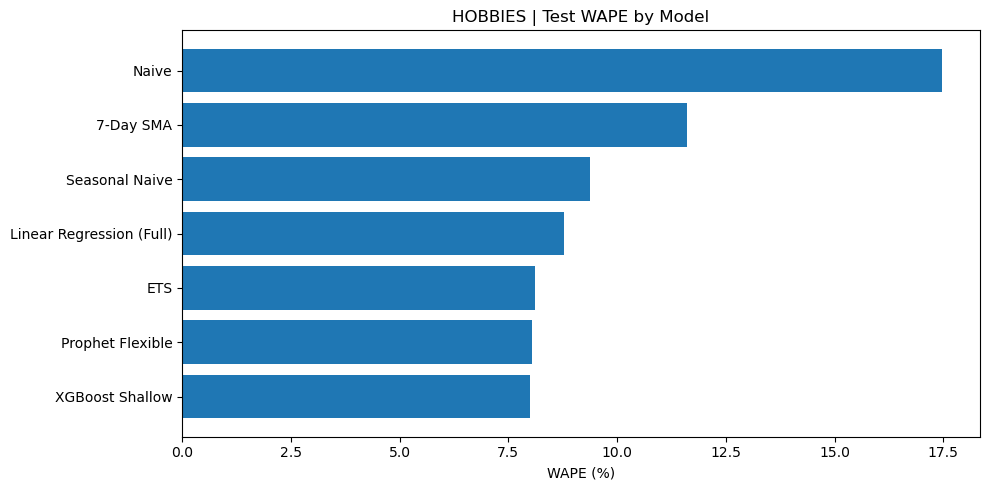

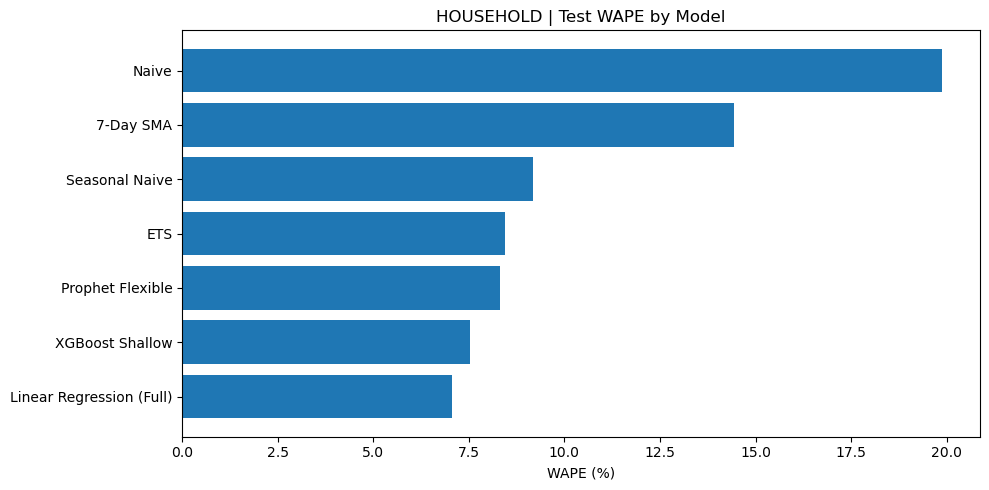

In [13]:
for category in test_report["cat_id"].unique():

    plot_data = test_report[
        test_report["cat_id"] == category
    ].sort_values("WAPE (%)")

    plt.figure(figsize=(10, 5))

    plt.barh(
        plot_data["Model"],
        plot_data["WAPE (%)"],
    )

    plt.title(
        f"{category} | Test WAPE by Model"
    )
    plt.xlabel("WAPE (%)")
    plt.tight_layout()
    plt.show()


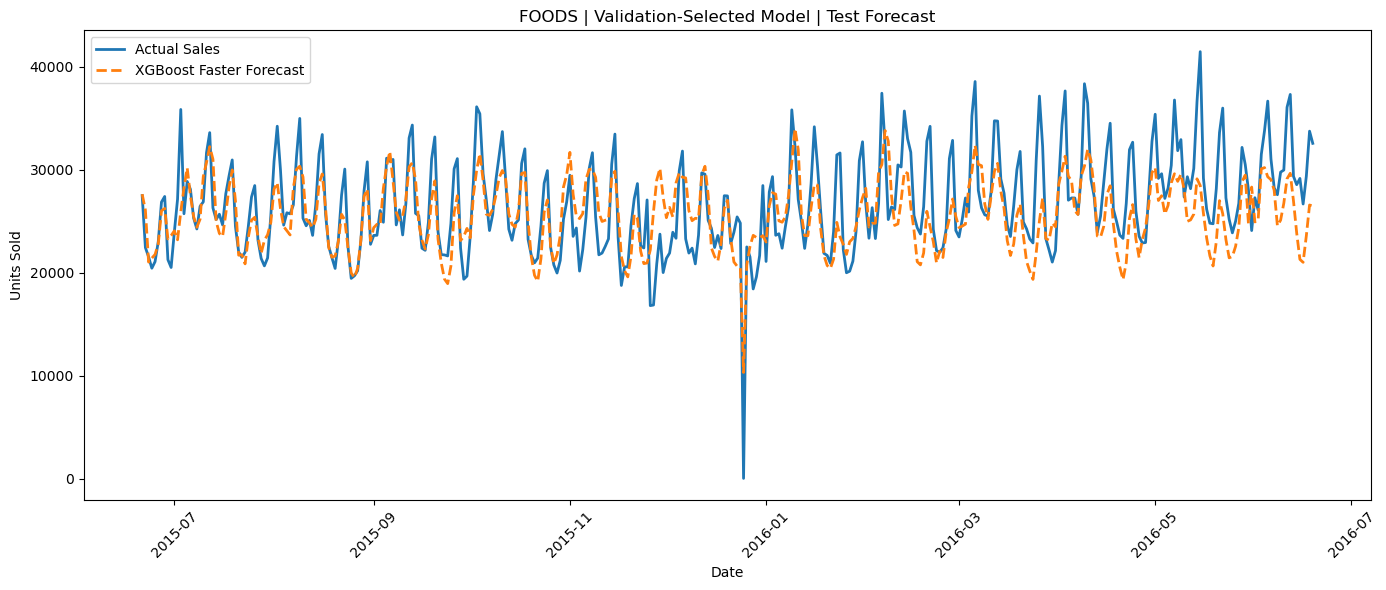

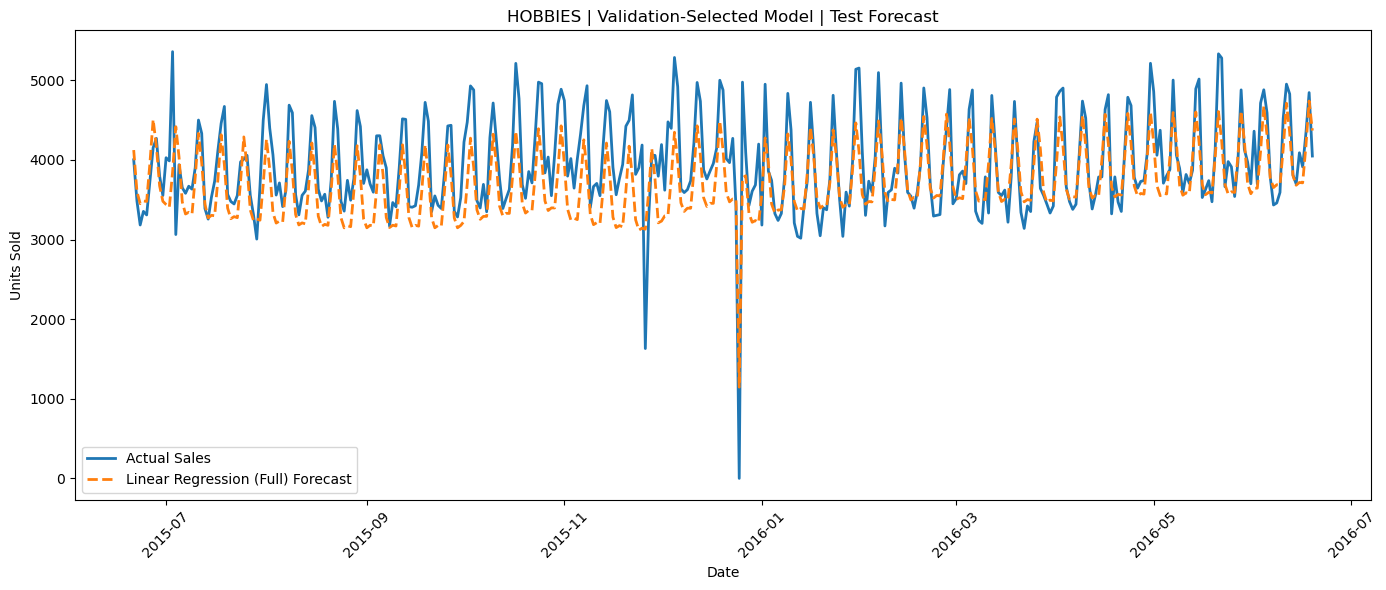

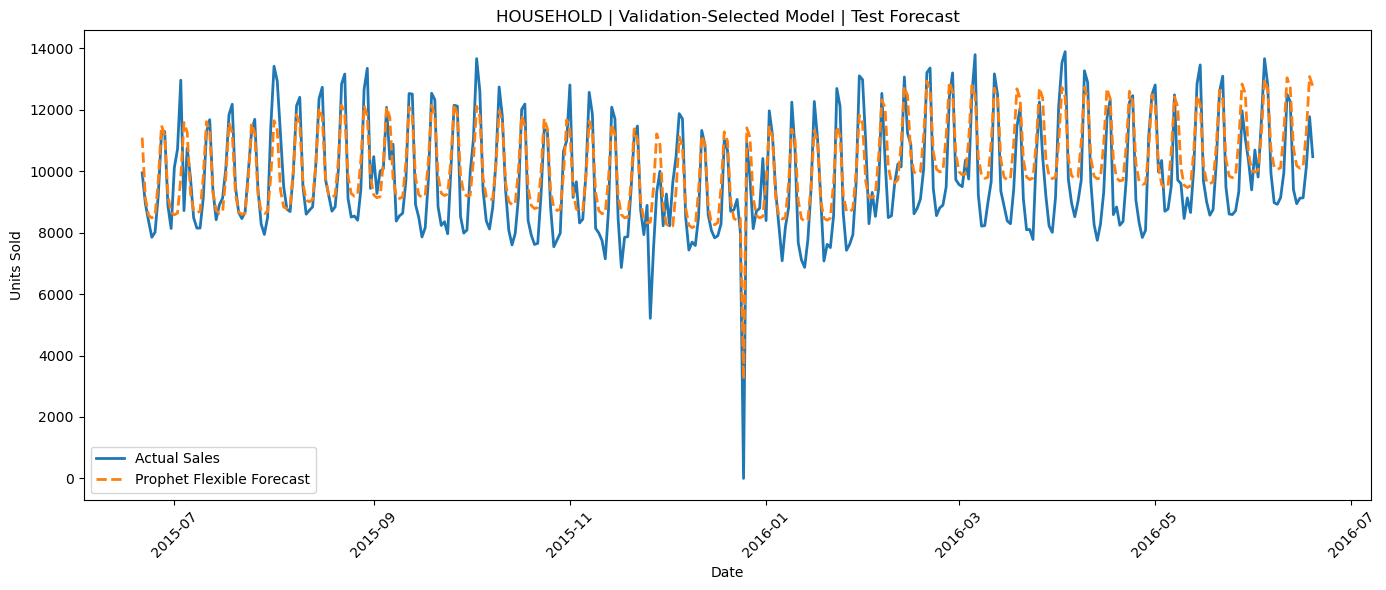

In [14]:
for category in selected_test_results["cat_id"]:

    selected_model = selected_test_results.loc[
        selected_test_results["cat_id"] == category,
        "Validation-selected model",
    ].iloc[0]

    plot_data = test_forecasts[
        (test_forecasts["cat_id"] == category)
        & (test_forecasts["Model"] == selected_model)
    ].sort_values("ds")

    plt.figure(figsize=(14, 6))

    plt.plot(
        plot_data["ds"],
        plot_data["actual"],
        label="Actual Sales",
        linewidth=2,
    )

    plt.plot(
        plot_data["ds"],
        plot_data["forecast"],
        label=f"{selected_model} Forecast",
        linestyle="--",
        linewidth=2,
    )

    plt.title(
        f"{category} | "
        f"Validation-Selected Model | Test Forecast"
    )
    plt.xlabel("Date")
    plt.ylabel("Units Sold")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [15]:
test_forecasts.to_parquet(
    "data/processed/final_test_forecasts.parquet",
    index=False,
)

test_metrics.to_parquet(
    "data/processed/final_test_metrics.parquet",
    index=False,
)

test_report.to_parquet(
    "data/processed/final_test_report.parquet",
    index=False,
)

selected_test_results.to_parquet(
    "data/processed/final_selected_model_test_results.parquet",
    index=False,
)


## Final Conclusion

The final test comparison shows that every advanced model improved on the Naive baseline. The validation-selected models also remained useful on unseen data, although their test WAPE was higher than their validation WAPE.

| Category | Validation-selected model | Test WAPE | Lowest observed test WAPE | Practical interpretation |
|---|---|---:|---|---|
| FOODS | XGBoost Faster | 10.22% | XGBoost Faster, 10.22% | XGBoost reduced WAPE by 5.88 points versus Naive. It is the strongest option here, although ETS was close at 10.69%. |
| HOBBIES | Linear Regression (Full) | 8.78% | XGBoost Shallow, 8.00% | The added XGBoost gain was modest: ETS and Prophet were also close. The extra complexity is not clearly justified by this small difference alone. |
| HOUSEHOLD | Prophet Flexible | 8.31% | Linear Regression (Full), 7.05% | Linear Regression provided the best observed test result and improved WAPE by 12.83 points versus Naive. XGBoost did not add enough value here. |

For this project, the main lesson is that added complexity is category-dependent. XGBoost was worthwhile for `FOODS`; it was not clearly worthwhile for `HOBBIES` or `HOUSEHOLD`, where simpler or medium-effort alternatives performed similarly or better. ETS remains a valuable benchmark because it was competitive for `FOODS` and `HOBBIES` with less modelling effort.

The models were selected during validation. The test table is a final fixed comparison, not another tuning cycle. The differences between validation and test performance show why the test set must remain separate until this stage.

### Limitations and next steps

- Forecasting is at daily category level; item, store, price, promotion, and inventory decisions remain outside this project.
- Long recursive forecasts can accumulate error when future lag values are based on earlier predictions.
- The test period is one historical year, so results should be monitored again if demand conditions change.
- The next operational step would be a separate allocation or replenishment template that consumes these forecasts rather than expanding this forecasting project.
